In [1]:
!pip install pyspark findspark matplotlib seaborn scipy scikit-learn

In [2]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, datediff, lit, to_date
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
# Create Spark session
spark = SparkSession.builder \
    .appName("Customer Segmentation") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

In [4]:
spark_df = spark.read.csv("flo_data_20k.csv", header=True, inferSchema=True)

In [5]:
print("First few rows of the dataset:")
spark_df.show(5)

First few rows of the dataset:
+--------------------+-------------+------------------+----------------+---------------+----------------------+-----------------------+---------------------------+----------------------------+---------------------------------+--------------------------------+---------------------------+
|           master_id|order_channel|last_order_channel|first_order_date|last_order_date|last_order_date_online|last_order_date_offline|order_num_total_ever_online|order_num_total_ever_offline|customer_value_total_ever_offline|customer_value_total_ever_online|interested_in_categories_12|
+--------------------+-------------+------------------+----------------+---------------+----------------------+-----------------------+---------------------------+----------------------------+---------------------------------+--------------------------------+---------------------------+
|cc294636-19f0-11e...|  Android App|           Offline|      2020-10-30|     2021-02-26|            2021-

In [6]:
print("Null count for each column:")
for col_name in spark_df.columns:
    null_count = spark_df.filter(col(col_name).isNull()).count()
    print(f"{col_name}: {null_count}")

Null count for each column:
master_id: 0
order_channel: 0
last_order_channel: 0
first_order_date: 0
last_order_date: 0
last_order_date_online: 0
last_order_date_offline: 0
order_num_total_ever_online: 0
order_num_total_ever_offline: 0
customer_value_total_ever_offline: 0
customer_value_total_ever_online: 0
interested_in_categories_12: 0


In [7]:
print("Basic statistics of the dataset:")
spark_df.describe().show()

Basic statistics of the dataset:
+-------+--------------------+-------------+------------------+---------------------------+----------------------------+---------------------------------+--------------------------------+---------------------------+
|summary|           master_id|order_channel|last_order_channel|order_num_total_ever_online|order_num_total_ever_offline|customer_value_total_ever_offline|customer_value_total_ever_online|interested_in_categories_12|
+-------+--------------------+-------------+------------------+---------------------------+----------------------------+---------------------------------+--------------------------------+---------------------------+
|  count|               19945|        19945|             19945|                      19945|                       19945|                            19945|                           19945|                      19945|
|   mean|                NULL|         NULL|              NULL|         3.1108548508398095|            

In [9]:
date_cols = ["first_order_date", "last_order_date",
             "last_order_date_online", "last_order_date_offline"]

for date_col in date_cols:
    spark_df = spark_df.withColumn(date_col, to_date(col(date_col)))

In [10]:
reference_date = lit("2021-06-01")

In [11]:
spark_df = spark_df.withColumn("recency", datediff(reference_date, col("last_order_date")))
spark_df = spark_df.withColumn("tenure", datediff(reference_date, col("first_order_date")))
spark_df = spark_df.withColumn("order_num_total",
                              col("order_num_total_ever_online") + col("order_num_total_ever_offline"))
spark_df = spark_df.withColumn("customer_value_total",
                              col("customer_value_total_ever_online") + col("customer_value_total_ever_offline"))

In [12]:
print("Calculated columns (recency, tenure, order_num_total, customer_value_total):")
spark_df.select("recency", "tenure", "order_num_total", "customer_value_total").show(5)

Calculated columns (recency, tenure, order_num_total, customer_value_total):
+-------+------+---------------+--------------------+
|recency|tenure|order_num_total|customer_value_total|
+-------+------+---------------+--------------------+
|     95|   214|            5.0|              939.37|
|    105|  1574|           21.0|             2013.55|
|    186|   552|            5.0|              585.32|
|    135|   146|            2.0|              121.97|
|     86|   668|            2.0|  209.98000000000002|
+-------+------+---------------+--------------------+
only showing top 5 rows



In [13]:
segmentation_cols = ["recency", "tenure", "order_num_total", "customer_value_total"]
segmentation_df = spark_df.select(segmentation_cols)

In [14]:
print("Statistics of segmentation features:")
segmentation_df.describe().show()

Statistics of segmentation features:
+-------+------------------+-----------------+-----------------+--------------------+
|summary|           recency|           tenure|  order_num_total|customer_value_total|
+-------+------------------+-----------------+-----------------+--------------------+
|  count|             19945|            19945|            19945|               19945|
|   mean|134.45836049135121|801.3028327901729|5.024768112308849|   751.2442872900963|
| stddev|103.28114867340973|523.3968829447795|4.742706967744824|   895.4021734204573|
|    min|                 2|                5|              2.0|               44.98|
|    max|               367|             3060|            202.0|             45905.1|
+-------+------------------+-----------------+-----------------+--------------------+



In [15]:
assembler = VectorAssembler(inputCols=segmentation_cols, outputCol="features")

In [16]:
scaler = MinMaxScaler(inputCol="features", outputCol="scaled_features")

In [17]:
pipeline = Pipeline(stages=[assembler, scaler])
pipeline_model = pipeline.fit(segmentation_df)
scaled_data = pipeline_model.transform(segmentation_df)

In [18]:
sse = []
for k in range(2, 11):
    kmeans = KMeans(k=k, seed=42, featuresCol="scaled_features")
    model = kmeans.fit(scaled_data)
    sse.append(model.summary.trainingCost)

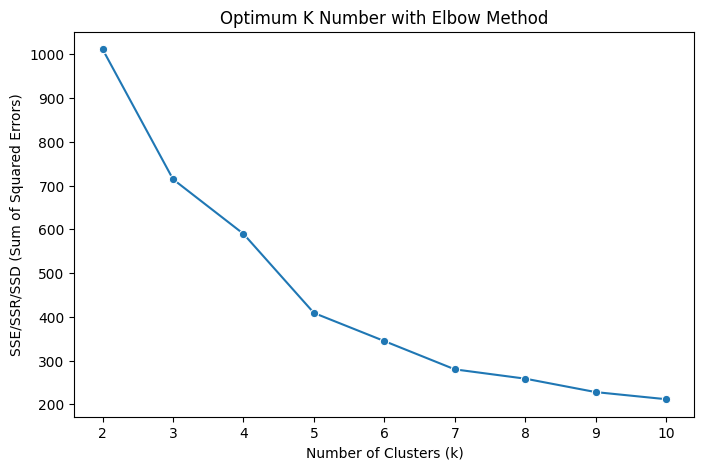

In [19]:
sse_df = pd.DataFrame({"k": range(2, 11), "sse": sse})

# Plot the elbow curve
plt.figure(figsize=(8, 5))
sns.lineplot(x="k", y="sse", data=sse_df, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE/SSR/SSD (Sum of Squared Errors)")
plt.title("Optimum K Number with Elbow Method")
plt.savefig("elbow_curve.png")
plt.show()

In [20]:
k_optimum = 4
kmeans = KMeans(k=k_optimum, seed=42, featuresCol="scaled_features")
kmeans_model = kmeans.fit(scaled_data)
kmeans_predictions = kmeans_model.transform(scaled_data)

In [21]:
pandas_df = spark_df.toPandas()
kmeans_pandas = kmeans_predictions.select("prediction", *segmentation_cols).toPandas()
pandas_df["kmeans_segment"] = kmeans_pandas["prediction"]

In [22]:
segment_analysis = pandas_df.groupby("kmeans_segment")[segmentation_cols].agg(["mean", "count", "median", "min", "max"])
print("K-Means Segment Analysis:")
print(segment_analysis)

K-Means Segment Analysis:
                   recency                               tenure         \
                      mean  count median  min  max         mean  count   
kmeans_segment                                                           
0                64.563388  10696   57.0    2  157   589.152113  10696   
1               271.141959   1113  273.0  170  367  1910.810422   1113   
2               246.304306   6293  234.0  153  367   662.415541   6293   
3                75.652740   1843   75.0    2  174  1836.734129   1843   

                                   order_num_total                            \
                median   min   max            mean  count median  min    max   
kmeans_segment                                                                 
0                600.0     5  1254        4.708022  10696    4.0  2.0   83.0   
1               1836.0  1155  3047        6.969452   1113    5.0  2.0   61.0   
2                635.0   161  1377        3.948196   62

In [23]:
segment_df = pandas_df.groupby("kmeans_segment")[segmentation_cols].mean().reset_index()
segment_df["segment"] = segment_df["kmeans_segment"]

segment_melted = segment_df.melt(id_vars="segment",
                                value_vars=segmentation_cols,
                                var_name="Metric", value_name="Value")

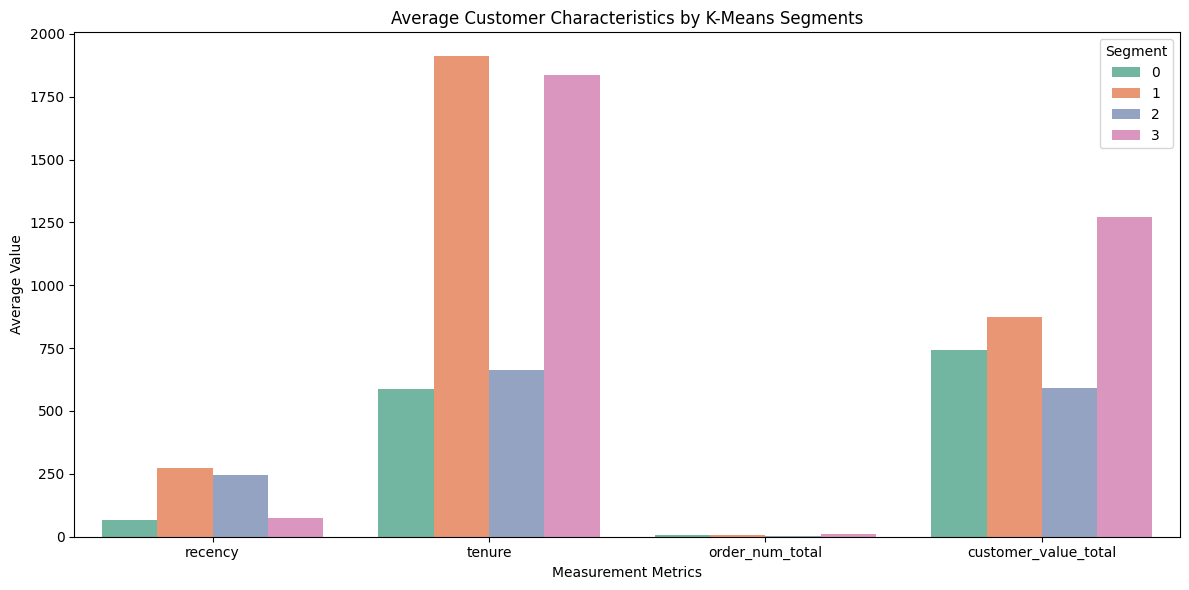

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(data=segment_melted, x="Metric", y="Value", hue="segment", palette="Set2")
plt.title("Average Customer Characteristics by K-Means Segments")
plt.xlabel("Measurement Metrics")
plt.ylabel("Average Value")
plt.legend(title="Segment")
plt.tight_layout()
plt.savefig("kmeans_segments.png")
plt.show()

In [25]:
from pyspark.ml.functions import vector_to_array

In [26]:
scaled_data_for_hierarchy = scaled_data.select(
    vector_to_array("scaled_features").alias("scaled_features_array")
).toPandas()

In [27]:
scaled_features_np = np.vstack(scaled_data_for_hierarchy["scaled_features_array"])

In [28]:
linked = linkage(scaled_features_np, method='ward')

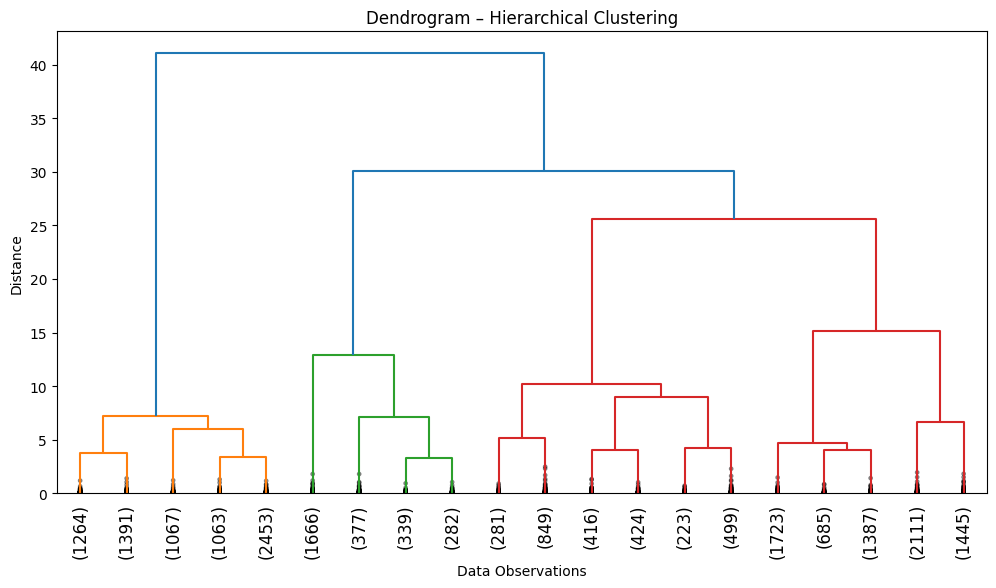

In [29]:
plt.figure(figsize=(12, 6))
dendrogram(linked,
         truncate_mode='lastp',
         p=20,
         leaf_rotation=90,
         leaf_font_size=12,
         show_contracted=True)
plt.title("Dendrogram – Hierarchical Clustering")
plt.xlabel("Data Observations")
plt.ylabel("Distance")
plt.savefig("dendrogram.png")
plt.show()

In [30]:
h_clusters = fcluster(linked, t=4, criterion='maxclust')

In [31]:
pandas_df["hierarchical_segment"] = h_clusters

In [32]:
hier_segment_analysis = pandas_df.groupby("hierarchical_segment")[segmentation_cols].agg(["mean", "count", "median", "min", "max"])
print("Hierarchical Segment Analysis:")
print(hier_segment_analysis)

Hierarchical Segment Analysis:
                         recency                              tenure        \
                            mean count median  min  max         mean count   
hierarchical_segment                                                         
1                      39.176568  7238   33.0    2  100   564.710279  7238   
2                     322.119369  2664  326.0  203  367  1027.455330  2664   
3                     101.622585  2692   94.0    2  262  1712.736999  2692   
4                     172.291933  7351  169.0   73  336   618.525779  7351   

                                        order_num_total                    \
                      median  min   max            mean count median  min   
hierarchical_segment                                                        
1                      586.0    5  1203        4.741779  7238    4.0  2.0   
2                      768.0  312  3047        4.377252  2664    3.0  2.0   
3                     1585.0   55  30

In [33]:
hier_segment_df = pandas_df.groupby("hierarchical_segment")[segmentation_cols].mean().reset_index()
hier_segment_df["segment"] = hier_segment_df["hierarchical_segment"]

hier_segment_melted = hier_segment_df.melt(id_vars="segment",
                                         value_vars=segmentation_cols,
                                         var_name="Metric", value_name="Value")

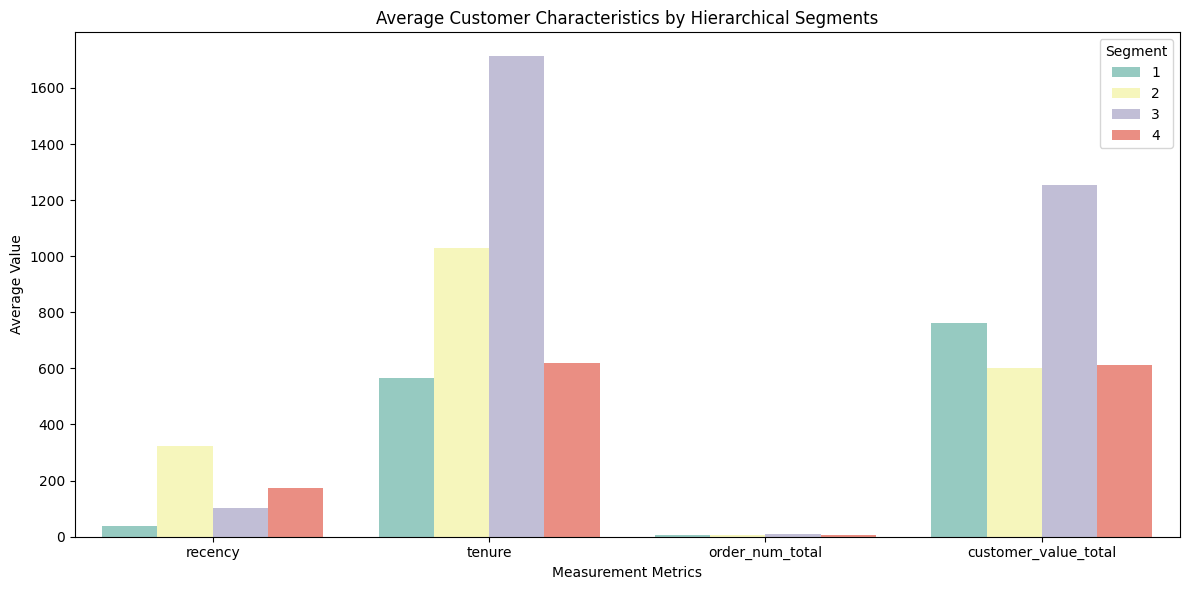

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=hier_segment_melted, x="Metric", y="Value", hue="segment", palette="Set3")
plt.title("Average Customer Characteristics by Hierarchical Segments")
plt.xlabel("Measurement Metrics")
plt.ylabel("Average Value")
plt.legend(title="Segment")
plt.tight_layout()
plt.savefig("hierarchical_segments.png")
plt.show()

In [35]:
bis_kmeans = BisectingKMeans(k=4, seed=42, featuresCol="scaled_features")
bis_model = bis_kmeans.fit(scaled_data)
bis_predictions = bis_model.transform(scaled_data)

In [36]:
bis_pandas = bis_predictions.select("prediction", *segmentation_cols).toPandas()
pandas_df["bisecting_kmeans_segment"] = bis_pandas["prediction"]

In [37]:
bis_segment_analysis = pandas_df.groupby("bisecting_kmeans_segment")[segmentation_cols].agg(["mean", "count", "median", "min", "max"])
print("BisectingKMeans Segment Analysis:")
print(bis_segment_analysis)

BisectingKMeans Segment Analysis:
                             recency                               tenure  \
                                mean  count median  min  max         mean   
bisecting_kmeans_segment                                                    
0                          66.465828  10886   59.0    2  164   587.853022   
1                          67.384435   1709   66.0    2  154  1823.098303   
2                         203.872152   4302  199.0  139  272   811.897722   
3                         316.931430   3048  322.0  224  367   975.773622   

                                                    order_num_total         \
                          count  median   min   max            mean  count   
bisecting_kmeans_segment                                                     
0                         10886   598.0     5  1208        4.684273  10886   
1                          1709  1711.0  1183  3060        9.516676   1709   
2                          4302   66

In [38]:
spark.stop()